In [1]:
import json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

ROOT    = Path('..')
REPORTS = ROOT / 'reports'

SEVERITY_COLORS = {
    'Critical':'#d62728','High':'#ff7f0e','Medium':'#f7c948',
    'Low':'#2ca02c','Negligible':'#aec7e8','Unknown':'#c7c7c7'
}

# ── Carga ─────────────────────────────────────────────────────────────────────
with open(REPORTS / 'repos.json') as f: repos_raw = json.load(f)
ORG = repos_raw['org']
df_repos = pd.DataFrame(repos_raw['repos'])
df_repos['pushed_at'] = pd.to_datetime(df_repos['pushed_at'])

with open(REPORTS / 'vulnerability_report.json') as f: vuln_raw = json.load(f)
results = [r for r in vuln_raw['results'] if 'error' not in r]
rows = []
for r in results:
    sc = r.get('severity_counts', {})
    rows.append({'repo':r['repo'],'total_vulns':r['total_vulnerabilities'],
                 'critical':sc.get('Critical',0),'high':sc.get('High',0),
                 'medium':sc.get('Medium',0),'low':sc.get('Low',0),
                 'negligible':sc.get('Negligible',0),'unknown':sc.get('Unknown',0),
                 'packages_affected':r.get('packages_affected_count',0),
                 'max_cvss':r.get('max_cvss_score',0.0),'fixable':r.get('fixable',0)})
df = pd.DataFrame(rows).sort_values('total_vulns',ascending=False).reset_index(drop=True)

with open(REPORTS / 'sbom_summary.json') as f: sbom_raw = json.load(f)
sbom_rows = []
for s in sbom_raw['sboms']:
    if 'error' in s: continue
    for eco, cnt in s.get('ecosystems',{}).items():
        sbom_rows.append({'repo':s['repo'],'ecosystem':eco,'components':cnt})
df_sbom = pd.DataFrame(sbom_rows) if sbom_rows else pd.DataFrame(columns=['repo','ecosystem','components'])
df_sbom_summary = pd.DataFrame([{'repo':s['repo'],'total_components':s.get('component_count',0)}
                                  for s in sbom_raw['sboms'] if 'error' not in s])

total_vulns    = df['total_vulns'].sum()
total_critical = df['critical'].sum()
total_high     = df['high'].sum()
total_medium   = df['medium'].sum()
total_low      = df['low'].sum()
total_fixable  = df['fixable'].sum()
fix_pct        = (total_fixable / total_vulns * 100) if total_vulns > 0 else 0
pct = lambda n: f'{n/total_vulns*100:.1f}%' if total_vulns > 0 else 'N/A'

display(Markdown(f'# Análisis SBOM + Vulnerabilidades — `{ORG}`'))
display(Markdown(f'**Repos analizados:** {len(df)} &nbsp;|&nbsp; **Total componentes:** {df_sbom_summary["total_components"].sum():,} &nbsp;|&nbsp; **Total vulnerabilidades:** {total_vulns:,}'))

# Análisis SBOM + Vulnerabilidades — `pallets`

**Repos analizados:** 1 &nbsp;|&nbsp; **Total componentes:** 101 &nbsp;|&nbsp; **Total vulnerabilidades:** 0

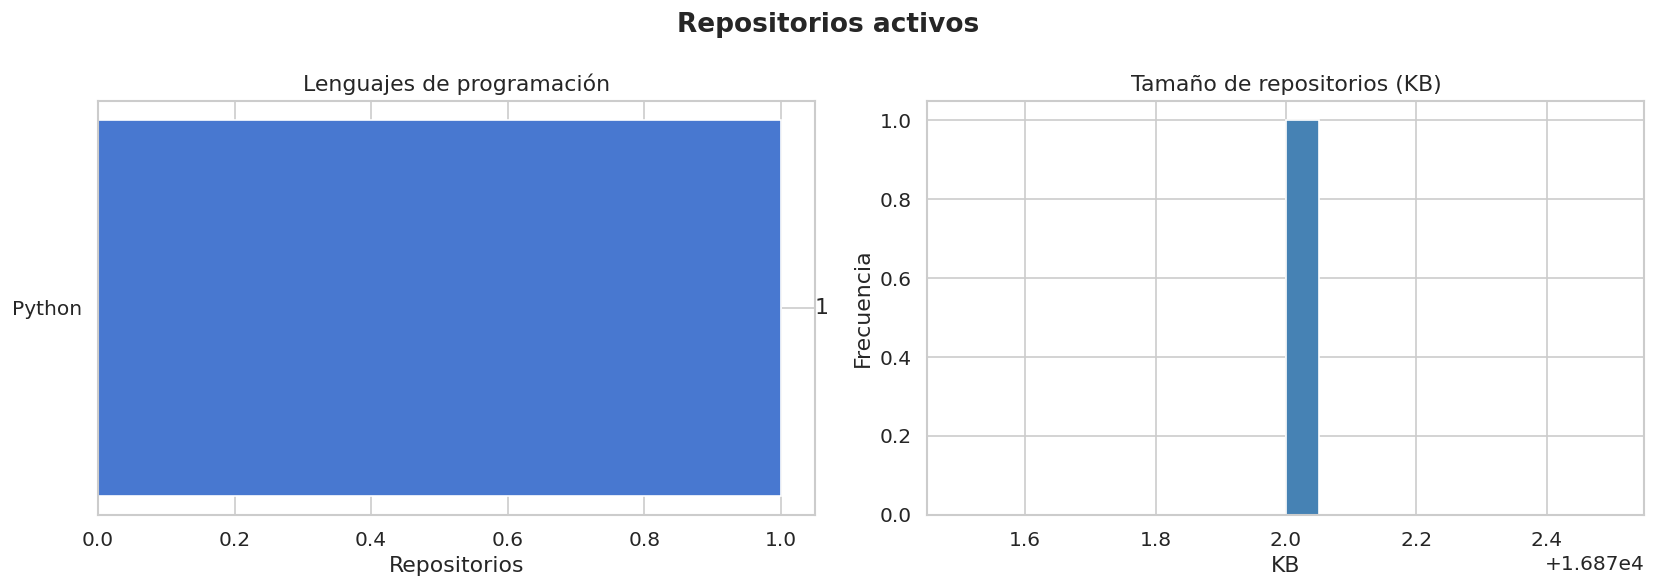

In [2]:
# ── Lenguajes y tamaño ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Repositorios activos', fontweight='bold')
lang_counts = df_repos['language'].fillna('Unknown').value_counts().head(12)
axes[0].barh(lang_counts.index[::-1], lang_counts.values[::-1],
             color=sns.color_palette('muted', len(lang_counts)))
axes[0].set_title('Lenguajes de programación'); axes[0].set_xlabel('Repositorios')
for i, v in enumerate(lang_counts.values[::-1]):
    axes[0].text(v+0.05, i, str(v), va='center')
axes[1].hist(df_repos['size_kb'].clip(upper=df_repos['size_kb'].quantile(0.95)),
             bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Tamaño de repositorios (KB)'); axes[1].set_xlabel('KB'); axes[1].set_ylabel('Frecuencia')
plt.tight_layout(); plt.savefig(REPORTS/'fig_repos.png',bbox_inches='tight'); plt.show()

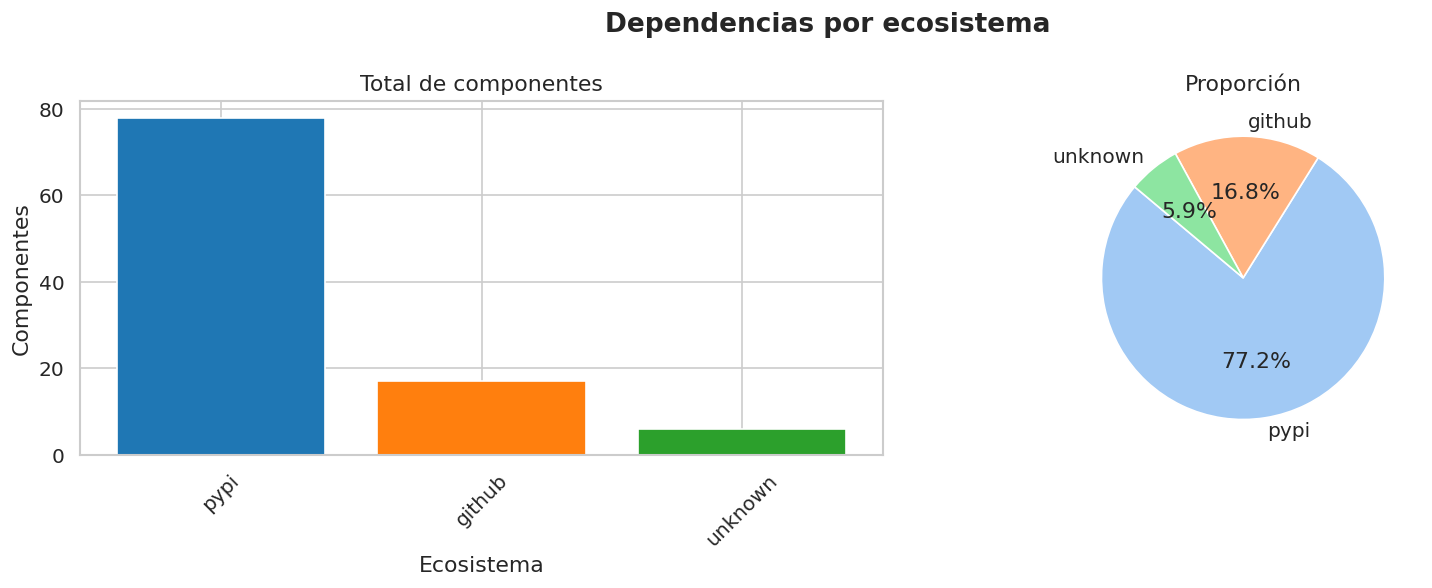

In [3]:
# ── Ecosistemas de dependencias ───────────────────────────────────────────────
if not df_sbom.empty:
    eco_total = df_sbom.groupby('ecosystem')['components'].sum().sort_values(ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Dependencias por ecosistema', fontweight='bold')
    palette = sns.color_palette('tab10', len(eco_total))
    axes[0].bar(eco_total.index, eco_total.values, color=palette)
    axes[0].set_title('Total de componentes'); axes[0].set_xlabel('Ecosistema')
    axes[0].set_ylabel('Componentes'); axes[0].tick_params(axis='x', rotation=45)
    top_n = min(8, len(eco_total))
    pie_data = eco_total.head(top_n).copy()
    if len(eco_total) > top_n: pie_data['otros'] = eco_total.iloc[top_n:].sum()
    axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
                colors=sns.color_palette('pastel', len(pie_data)), startangle=140)
    axes[1].set_title('Proporción')
    plt.tight_layout(); plt.savefig(REPORTS/'fig_ecosystems.png',bbox_inches='tight'); plt.show()

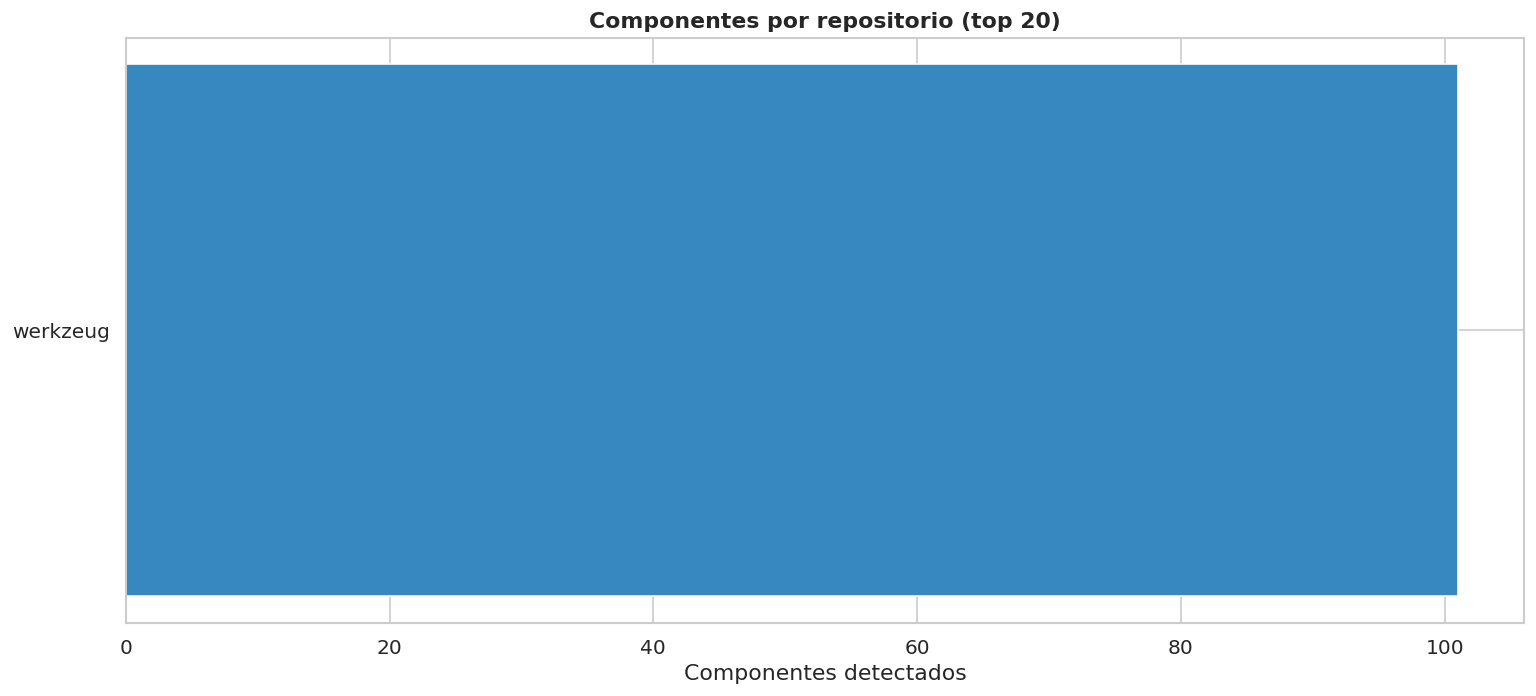

In [4]:
# ── Componentes por repo ──────────────────────────────────────────────────────
top_comp = df_sbom_summary.sort_values('total_components', ascending=False).head(20)
plt.figure(figsize=(13, 6))
plt.barh(top_comp['repo'][::-1], top_comp['total_components'][::-1],
         color=sns.color_palette('Blues_d', len(top_comp)))
plt.title('Componentes por repositorio (top 20)', fontweight='bold')
plt.xlabel('Componentes detectados')
plt.tight_layout(); plt.savefig(REPORTS/'fig_components_per_repo.png',bbox_inches='tight'); plt.show()

In [5]:
# ── Resumen de vulnerabilidades ───────────────────────────────────────────────
display(Markdown(f"""
## Resumen de vulnerabilidades
| Métrica | Valor |
|---|---|
| Total vulnerabilidades | {total_vulns:,} |
| 🔴 Critical | {total_critical:,} ({pct(total_critical)}) |
| 🟠 High | {total_high:,} ({pct(total_high)}) |
| 🟡 Medium | {total_medium:,} ({pct(total_medium)}) |
| 🟢 Low | {total_low:,} ({pct(total_low)}) |
| Corregibles | {total_fixable:,} ({fix_pct:.1f}%) |
| CVSS máximo | {df['max_cvss'].max():.1f} |
"""))


## Resumen de vulnerabilidades
| Métrica | Valor |
|---|---|
| Total vulnerabilidades | 0 |
| 🔴 Critical | 0 (N/A) |
| 🟠 High | 0 (N/A) |
| 🟡 Medium | 0 (N/A) |
| 🟢 Low | 0 (N/A) |
| Corregibles | 0 (0.0%) |
| CVSS máximo | 0.0 |


In [6]:
# ── Distribución de severidad ─────────────────────────────────────────────────
sev_series = pd.Series({'Critical':total_critical,'High':total_high,'Medium':total_medium,
                         'Low':total_low,'Negligible':df['negligible'].sum(),'Unknown':df['unknown'].sum()})
sev_series = sev_series[sev_series > 0]
if not sev_series.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribución de severidad', fontweight='bold')
    bar_colors = [SEVERITY_COLORS.get(s,'#999') for s in sev_series.index]
    axes[0].bar(sev_series.index, sev_series.values, color=bar_colors, edgecolor='white')
    axes[0].set_ylabel('Cantidad')
    for i, v in enumerate(sev_series.values):
        axes[0].text(i, v+sev_series.max()*0.01, f'{v:,}', ha='center', fontweight='bold')
    axes[1].pie(sev_series, labels=sev_series.index, colors=bar_colors, autopct='%1.1f%%', startangle=90)
    plt.tight_layout(); plt.savefig(REPORTS/'fig_severity.png',bbox_inches='tight'); plt.show()
else:
    display(Markdown('> ✅ No se encontraron vulnerabilidades en los repositorios analizados.'))

> ✅ No se encontraron vulnerabilidades en los repositorios analizados.

In [7]:
# ── Top 20 repos más vulnerables ──────────────────────────────────────────────
if total_vulns > 0:
    top20 = df.head(20).copy()
    sev_cols   = ['critical','high','medium','low','negligible','unknown']
    sev_labels = ['Critical','High','Medium','Low','Negligible','Unknown']
    fig, ax = plt.subplots(figsize=(14, 8))
    bottom = np.zeros(len(top20))
    for col, label in zip(sev_cols, sev_labels):
        vals = top20[col].values
        if vals.sum() == 0: continue
        ax.barh(top20['repo'][::-1], vals[::-1], left=bottom[::-1],
                label=label, color=SEVERITY_COLORS[label], edgecolor='white', linewidth=0.3)
        bottom += vals
    ax.set_title('Top 20 repositorios por vulnerabilidades', fontweight='bold')
    ax.set_xlabel('Vulnerabilidades')
    handles = [mpatches.Patch(color=SEVERITY_COLORS[s], label=s)
               for s in sev_labels if df[s.lower()].sum() > 0]
    if handles: ax.legend(handles=handles, loc='lower right')
    plt.tight_layout(); plt.savefig(REPORTS/'fig_top20_repos.png',bbox_inches='tight'); plt.show()

In [8]:
# ── CVSS scores ───────────────────────────────────────────────────────────────
all_vulns = []
for r in results:
    for v in r.get('vulnerabilities', []):
        for cvss_entry in v.get('cvss', []):
            score = cvss_entry.get('metrics', {}).get('baseScore')
            if score is not None:
                all_vulns.append({'severity':v['severity'],'cvss_score':float(score),'fix_state':v.get('fix_state','unknown')})
                break
df_vulns = pd.DataFrame(all_vulns)
if not df_vulns.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Scores CVSS', fontweight='bold')
    axes[0].hist(df_vulns['cvss_score'], bins=20, color='steelblue', edgecolor='white')
    axes[0].axvline(7.0, color='orange', linestyle='--', label='High (7.0)')
    axes[0].axvline(9.0, color='red',    linestyle='--', label='Critical (9.0)')
    axes[0].set_title('Distribución'); axes[0].set_xlabel('CVSS Score'); axes[0].legend()
    cvss_by_sev = df_vulns.groupby('severity')['cvss_score'].mean().sort_values(ascending=False)
    axes[1].bar(cvss_by_sev.index, cvss_by_sev.values,
                color=[SEVERITY_COLORS.get(s,'#999') for s in cvss_by_sev.index])
    axes[1].set_title('Promedio por severidad'); axes[1].set_ylabel('CVSS promedio'); axes[1].set_ylim(0,10)
    plt.tight_layout(); plt.savefig(REPORTS/'fig_cvss.png',bbox_inches='tight'); plt.show()

    fix_colors = {'fixed':'#2ca02c','not-fixed':'#d62728','wont-fix':'#ff7f0e','unknown':'#c7c7c7'}
    fix_counts = df_vulns['fix_state'].value_counts()
    plt.figure(figsize=(7,5))
    plt.bar(fix_counts.index, fix_counts.values,
            color=[fix_colors.get(s,'#999') for s in fix_counts.index], edgecolor='white')
    plt.title('Estado de corrección', fontweight='bold'); plt.ylabel('Cantidad')
    for i,v in enumerate(fix_counts.values): plt.text(i, v+fix_counts.max()*0.01, f'{v:,}', ha='center')
    plt.tight_layout(); plt.savefig(REPORTS/'fig_fixability.png',bbox_inches='tight'); plt.show()
else:
    display(Markdown('> ℹ️ No hay scores CVSS disponibles.'))

> ℹ️ No hay scores CVSS disponibles.

In [9]:
# ── Top CVEs ──────────────────────────────────────────────────────────────────
all_cve_list = [{'cve_id':v['id'],'severity':v['severity']}
                for r in results for v in r.get('vulnerabilities',[])]
df_cves_all = pd.DataFrame(all_cve_list)
if not df_cves_all.empty:
    top_cves = df_cves_all['cve_id'].value_counts().head(15)
    cve_sev  = df_cves_all.drop_duplicates('cve_id').set_index('cve_id')['severity']
    plt.figure(figsize=(13,6))
    plt.barh(top_cves.index[::-1], top_cves.values[::-1],
             color=[SEVERITY_COLORS.get(cve_sev.get(c,'Unknown'),'#999') for c in top_cves.index[::-1]])
    plt.title('Top 15 CVEs más frecuentes', fontweight='bold'); plt.xlabel('Repositorios afectados')
    handles = [mpatches.Patch(color=SEVERITY_COLORS[s],label=s)
               for s in ['Critical','High','Medium','Low'] if s in cve_sev.values]
    if handles: plt.legend(handles=handles, loc='lower right')
    plt.tight_layout(); plt.savefig(REPORTS/'fig_top_cves.png',bbox_inches='tight'); plt.show()
else:
    display(Markdown('> ℹ️ No se encontraron CVEs.'))

> ℹ️ No se encontraron CVEs.

In [10]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
heat_data = df.set_index('repo')[['critical','high','medium','low']].head(25)
if heat_data.shape[0] >= 2 and heat_data.values.sum() > 0:
    plt.figure(figsize=(9, max(6, heat_data.shape[0]*0.4)))
    sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.4, linecolor='white', cbar_kws={'label':'Vulnerabilidades'})
    plt.title('Heatmap: vulnerabilidades por repo y severidad', fontweight='bold')
    plt.xticks(rotation=0); plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout(); plt.savefig(REPORTS/'fig_heatmap.png',bbox_inches='tight'); plt.show()

In [11]:
# ── Correlaciones ─────────────────────────────────────────────────────────────
df_merged = df_sbom_summary.merge(df[['repo','total_vulns','critical','max_cvss']], on='repo', how='inner')
if len(df_merged) > 3:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle('Correlaciones', fontweight='bold')
    axes[0].scatter(df_merged['total_components'], df_merged['total_vulns'], alpha=0.7, color='steelblue', s=80)
    z = np.polyfit(df_merged['total_components'], df_merged['total_vulns'], 1)
    xp = np.linspace(df_merged['total_components'].min(), df_merged['total_components'].max(), 100)
    axes[0].plot(xp, np.poly1d(z)(xp), 'r--', alpha=0.8)
    corr = df_merged['total_components'].corr(df_merged['total_vulns'])
    axes[0].set_title(f'Componentes vs Vulnerabilidades (r={corr:.2f})')
    axes[0].set_xlabel('Componentes'); axes[0].set_ylabel('Vulnerabilidades')
    sc = axes[1].scatter(df_merged['total_components'], df_merged['max_cvss'],
                         c=df_merged['critical'], cmap='Reds', alpha=0.8, s=90)
    plt.colorbar(sc, ax=axes[1], label='Vulns Critical')
    axes[1].set_title('Componentes vs CVSS máximo')
    axes[1].set_xlabel('Componentes'); axes[1].set_ylabel('CVSS máximo')
    plt.tight_layout(); plt.savefig(REPORTS/'fig_correlations.png',bbox_inches='tight'); plt.show()

In [12]:
# ── Tabla de riesgo y conclusiones ────────────────────────────────────────────
df_risk = df.copy()
df_risk['risk_score'] = df_risk['critical']*10 + df_risk['high']*5 + df_risk['medium']*2 + df_risk['low']*1
df_risk = df_risk.sort_values('risk_score', ascending=False)

display(Markdown('## Tabla de riesgo — `Critical×10 + High×5 + Medium×2 + Low×1`'))
display(
    df_risk[['repo','total_vulns','critical','high','medium','low','fixable','max_cvss','risk_score']]
    .head(15).rename(columns={'repo':'Repositorio','total_vulns':'Total','critical':'Critical',
        'high':'High','medium':'Medium','low':'Low','fixable':'Corregibles',
        'max_cvss':'CVSS máx','risk_score':'Risk Score'})
    .style.background_gradient(subset=['Risk Score'],cmap='Reds')
    .background_gradient(subset=['Critical'],cmap='OrRd')
    .format({'CVSS máx':'{:.1f}','Risk Score':'{:,.0f}'})
)

pct_crit_repos = (df['critical']>0).sum()/len(df)*100 if len(df)>0 else 0
eco_top3 = ', '.join(df_sbom.groupby('ecosystem')['components'].sum()
                     .sort_values(ascending=False).head(3).index.tolist()) if not df_sbom.empty else 'N/A'
top_risky = df_risk.iloc[0]['repo'] if len(df_risk)>0 else 'N/A'

display(Markdown(f"""
## Conclusiones — `{ORG}`
- **{len(df)} repositorios** activos analizados.
- **{df_sbom_summary['total_components'].sum():,} componentes** detectados. Ecosistemas principales: {eco_top3}.
- **{total_vulns:,} vulnerabilidades** totales. El **{pct_crit_repos:.0f}%** de los repos tiene al menos una crítica.
- Promedio de **{df['total_vulns'].mean():.1f} vulnerabilidades por repositorio**.
- **{fix_pct:.1f}%** de las vulnerabilidades tiene fix disponible.
- Repositorio de mayor riesgo: **`{top_risky}`** (Risk Score: {df_risk.iloc[0]['risk_score']:,.0f}).

### Recomendaciones
1. Priorizar repos con vulnerabilidades **Critical** y **High** con fix disponible.
2. Integrar Syft + Grype en el CI/CD para detección continua.
3. Establecer SLAs: Critical → fix en 7 días, High → 30 días.
"""))

## Tabla de riesgo — `Critical×10 + High×5 + Medium×2 + Low×1`

,Repositorio,Total,Critical,High,Medium,Low,Corregibles,CVSS máx,Risk Score
0,werkzeug,0,0,0,0,0,0,0.0,0



## Conclusiones — `pallets`
- **1 repositorios** activos analizados.
- **101 componentes** detectados. Ecosistemas principales: pypi, github, unknown.
- **0 vulnerabilidades** totales. El **0%** de los repos tiene al menos una crítica.
- Promedio de **0.0 vulnerabilidades por repositorio**.
- **0.0%** de las vulnerabilidades tiene fix disponible.
- Repositorio de mayor riesgo: **`werkzeug`** (Risk Score: 0).

### Recomendaciones
1. Priorizar repos con vulnerabilidades **Critical** y **High** con fix disponible.
2. Integrar Syft + Grype en el CI/CD para detección continua.
3. Establecer SLAs: Critical → fix en 7 días, High → 30 días.
